## Задача (12 pts)

Рассмотрим следующую задачу

$$ \min_x \frac12 \|x - y \|_2^2 + \lambda \sum_{i=0}^{n-1} \left(\sqrt{\varepsilon^2 + (x_{i+1} - x_i)^2} - \varepsilon\right),$$

где $y$ данный вектор, $\lambda >0 $ и $\varepsilon > 0$ заданные числа. 

- (6 pts) Сравните для этой задачи скорость сходимости (по итерациям и по времени) градиентного спуска для 3 разных постоянных шагов (убедитесь что они все приводят к сходимости). Избыточное использование циклов в коде приведёт к снижению баллов за этот пункт.

Прокомментируйте и объясните полученный результат.


- (1 pts) Нарисуйте на одном графике векторы $y$ и $x^*$. Что вы заметили? 
- (5 pts) Повторите эксперименты для $\varepsilon = 10^{-2}$ и $\varepsilon = 10^{-4}$. Что изменилось в результате и сходимости градиентного спуска и почему? Какую роль играет этот параметр в постановке задачи?

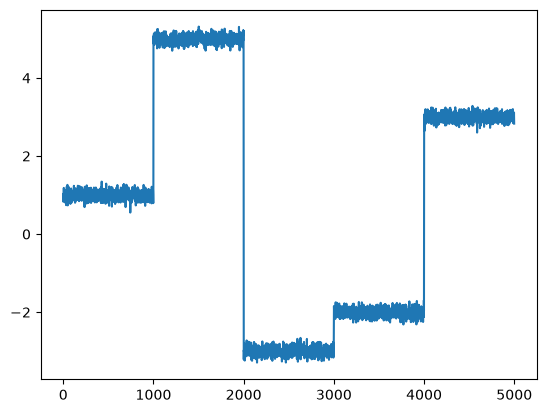

In [41]:
import numpy as np
import matplotlib.pyplot as plt
n = 5000
EPSILON = 0.001
LAMBDA = 50
y = np.hstack([np.ones(1000) + 0.1 * np.random.randn(1000), 5 * np.ones(1000) + 0.1 *np.random.randn(1000),
                   -3*np.ones(1000) + 0.1 *np.random.randn(1000), -2 * np.ones(1000) + 0.1 *np.random.randn(1000),
                  3 * np.ones(1000) + 0.1 *np.random.randn(1000)])
plt.plot(y)

In [42]:
# # 2. Функция и градиент без циклов по координатам.
from time import perf_counter

def f(x, y, epsilon, lamda):
    d = np.diff(x)
    g = x - y
    penalty = np.sqrt(epsilon**2 + d**2) - epsilon
    return 0.5 * np.dot(g, g) + lamda * penalty.sum()

def gradient(x, y, epsilon, lamda):
    d = np.diff(x)
    q = lamda * d / np.sqrt(epsilon**2 + d**2)
    g = x - y
    g[:-1] -= q
    g[1:] += q
    return g

In [43]:
def gradient_descent(y, eps, lam, factor, tol=1e-3, log_every=100, max_iter=5000):
    x = np.array(y, dtype=float, copy=True)
    L = 1.0 + 4.0 * lam / eps
    alpha = factor / L
    if not 0.0 < alpha < 2.0 / L:
        raise ValueError("Шаг должен лежать строго между 0 и 2/L")
    if max_iter < 0 or log_every < 1:
        raise ValueError("Нужны max_iter >= 0 и log_every >= 1")

    history = []
    start = perf_counter()
    g = gradient(x, y, eps, lam)

    # k — число уже выполненных шагов; k=0 соответствует начальному x=y.
    for k in range(max_iter + 1):
        error = np.sqrt(np.mean(g*g))
        converged = error <= tol
        # Ошибка и значение функции относятся к одному и тому же x.
        # Последняя точка записывается даже между интервалами log_every.
        if k <= 10 or k % log_every == 0 or k == max_iter or converged:
            value = f(x, y, eps, lam)
            elapsed = perf_counter() - start
            history.append((k, elapsed, error, value))

        if converged or k == max_iter:
            return {
                "x": x,
                "factor": factor,
                "alpha": alpha,
                "history": np.asarray(history),
                "converged": bool(converged),
            }

        x -= alpha * g
        g = gradient(x, y, eps, lam)


eps     alpha*L    iterations    seconds    grad RMS       f(x)    status
1e-03     0.5          5000       0.12    9.011e-01    933.98656    лимит итераций
1e-03     1.0          5000       0.12    3.197e-01    916.33323    лимит итераций
1e-03     1.8          5000       0.14    2.070e-01    910.14433    лимит итераций
1e-02     0.5          5000       0.12    2.374e-01    844.22711    лимит итераций
1e-02     1.0          5000       0.12    1.733e-01    818.55059    лимит итераций
1e-02     1.8          5000       0.12    1.155e-01    798.36040    лимит итераций
1e-04     0.5          5000       0.12    3.763e+01    6813.03789    лимит итераций
1e-04     1.0          5000       0.12    1.659e+01    2606.27185    лимит итераций
1e-04     1.8          5000       0.12    6.891e+00    1369.20573    лимит итераций


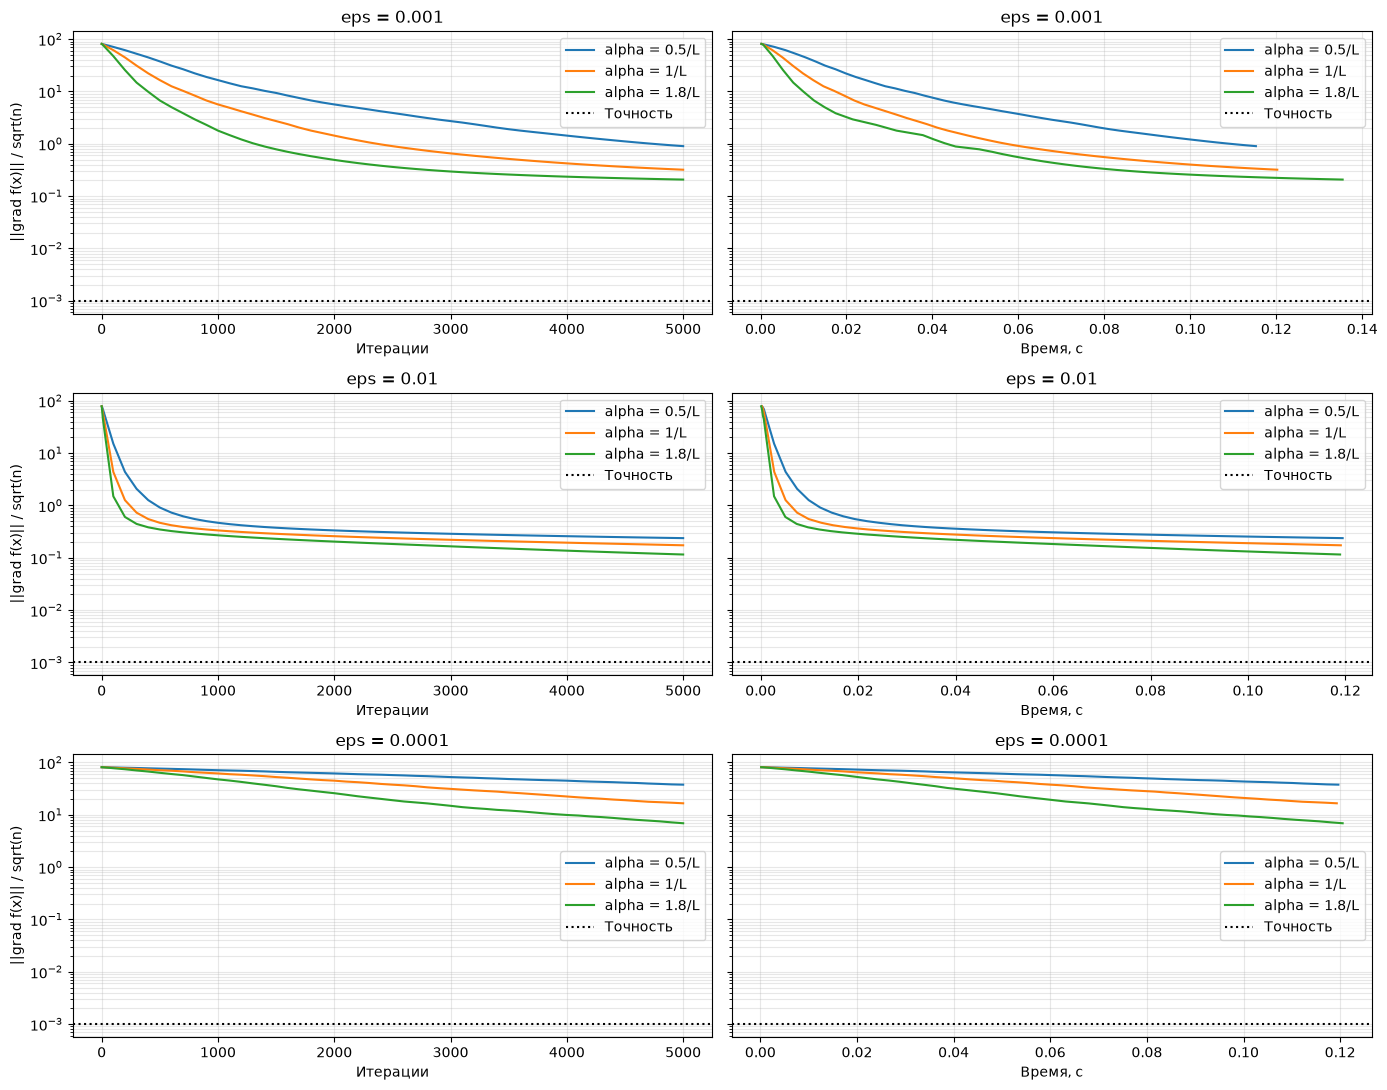

In [44]:
# # 4. Эксперименты: одинаковые y, начальная точка и точность.
# # Используем y из условия; между запусками заново шум не генерируем.
# # Для воспроизводимости между сессиями можно поставить np.random.seed(42)
# # ПЕРЕД генерацией y в исходной ячейке.
# # При eps=1e-4 расчёт может занять несколько минут: нужны миллионы шагов.
# # L и alpha пересчитываются для нового eps, но внутри запуска шаг постоянен.
# 
y_fixed = np.array(y, dtype=float, copy=True)
eps_values = (1e-3, 1e-2, 1e-4)
factors = (0.5, 1.0, 1.8)
tol = 1e-3
max_iter = 5000  # Короткий прогон; для достижения tol может понадобиться больше шагов.
experiments = {}
print("eps     alpha*L    iterations    seconds    grad RMS       f(x)    status")
for eps in eps_values:
    experiments[eps] = []
    for factor in factors:
        run = gradient_descent(y_fixed, eps, LAMBDA, factor, tol=tol, max_iter=max_iter)
        experiments[eps].append(run)
        k, seconds, error, value = run["history"][-1]
        status = "сошёлся" if run["converged"] else "лимит итераций"
        print(f"{eps:.0e}     {factor:3.1f}    {int(k):10d}    {seconds:7.2f}"
              f"    {error:.3e}    {value:.5f}    {status}", flush=True)

# Левая колонка — число итераций, правая — время работы.
# При статусе «лимит итераций» это только часть траектории до минимума.
fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharey=True)
for row, eps in enumerate(eps_values):
    for run in experiments[eps]:
        h = run["history"]
        label = f"alpha = {run['factor']:g}/L"
        axes[row, 0].semilogy(h[:, 0], h[:, 2], label=label)
        axes[row, 1].semilogy(h[:, 1], h[:, 2], label=label)
    axes[row, 0].set_xlabel("Итерации")
    axes[row, 1].set_xlabel("Время, с")
    axes[row, 0].set_ylabel("||grad f(x)|| / sqrt(n)")
    for ax in axes[row]:
        ax.axhline(tol, color="black", linestyle=":", label="Точность")
        ax.set_title(f"eps = {eps:g}")
        ax.grid(True, which="both", alpha=0.3)
        ax.legend()
fig.tight_layout()
plt.show()


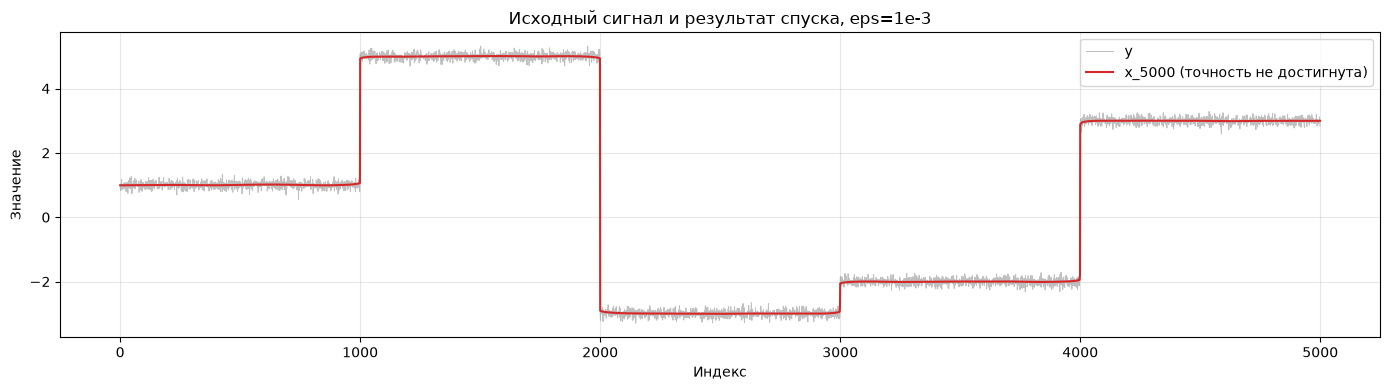

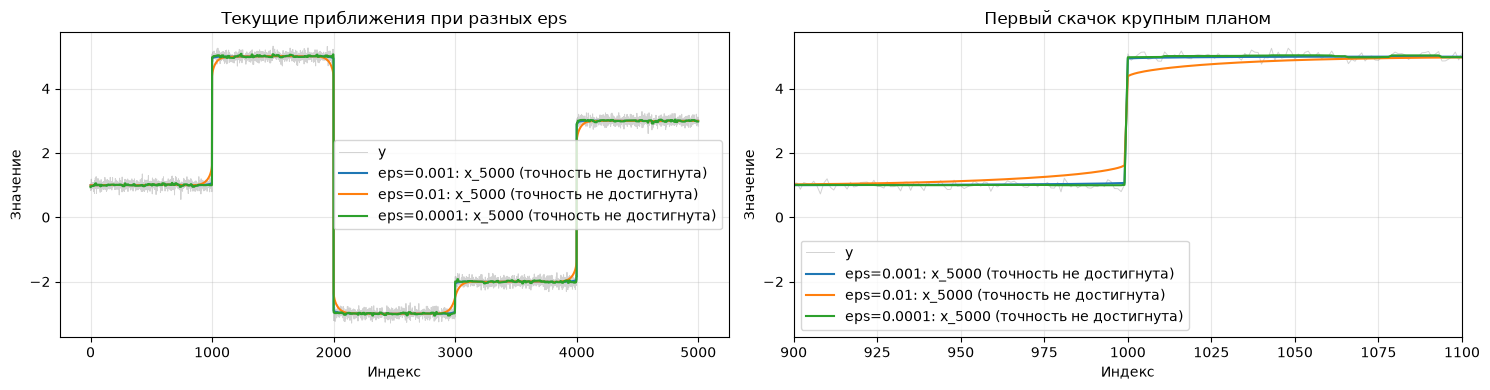

In [45]:
# Если точность не достигнута, показываем текущий x_k, а не называем его x*.
# Проверяем каждый eps отдельно: приближение можно нарисовать и до сходимости.
def solution_label(run):
    k = int(run["history"][-1][0])
    error = run["history"][-1][2]
    converged = np.isfinite(error) and error <= tol
    return "x* (точность достигнута)" if converged else f"x_{k} (точность не достигнута)"


base_run = experiments[1e-3][-1]
x_estimate = base_run["x"]
plt.figure(figsize=(14, 4))
plt.plot(y_fixed, color="gray", alpha=0.5, linewidth=0.7, label="y")
plt.plot(x_estimate, color="tab:red", linewidth=1.5, label=solution_label(base_run))
plt.xlabel("Индекс")
plt.ylabel("Значение")
plt.title("Исходный сигнал и результат спуска, eps=1e-3")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# При разных eps и незавершённой оптимизации сравниваются именно x_k.
all_solutions_converged = all(
    np.isfinite(experiments[eps][-1]["history"][-1][2])
    and experiments[eps][-1]["history"][-1][2] <= tol
    for eps in eps_values
)
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax in axes:
    ax.plot(y_fixed, color="gray", alpha=0.35, linewidth=0.7, label="y")
    for eps in eps_values:
        run = experiments[eps][-1]
        ax.plot(run["x"], linewidth=1.5, label=f"eps={eps:g}: {solution_label(run)}")
    ax.set_xlabel("Индекс")
    ax.set_ylabel("Значение")
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_title("Решения при разных eps" if all_solutions_converged else "Текущие приближения при разных eps")
axes[1].set_title("Первый скачок крупным планом")
axes[1].set_xlim(900, 1100)
fig.tight_layout()
plt.show()


In [46]:
# Выводы по текущему запуску, а не по старой таблице результатов.
def print_conclusions(experiments, eps_values, tol):
    summaries = {}
    for eps in eps_values:
        summaries[eps] = []
        for run in experiments.get(eps, []):
            # Два последовательных индекса работают и со списком, и с ndarray.
            k, seconds, error, value = run["history"][-1]
            summaries[eps].append({
                "factor": run["factor"], "k": int(k), "seconds": seconds,
                "error": error,
                # Проверяем текущий tol по фактическому остатку.
                "converged": bool(np.isfinite(error) and error <= tol),
            })

    total_runs = sum(len(runs) for runs in summaries.values())
    if total_runs == 0:
        print("Нет результатов: сначала выполни ячейку экспериментов.")
        return
    converged_runs = sum(run["converged"] for runs in summaries.values() for run in runs)
    print(f"Точность {tol:g} достигнута в {converged_runs} из {total_runs} запусков.")

    for eps, runs in summaries.items():
        if not runs:
            print(f"eps={eps:g}: результатов пока нет.")
            continue
        if all(run["converged"] for run in runs):
            best_iterations = min(runs, key=lambda run: run["k"])
            best_time = min(runs, key=lambda run: run["seconds"])
            print(f"eps={eps:g}: среди полученных запусков до общей точности меньше "
                  f"итераций у шага {best_iterations['factor']:g}/L, меньше времени — "
                  f"у {best_time['factor']:g}/L.")
        elif len({run["k"] for run in runs}) == 1:
            ordered = sorted(runs, key=lambda run: run["error"])
            ranking = ", ".join(f"{run['factor']:g}/L" for run in ordered)
            print(f"eps={eps:g}: после {runs[0]['k']} шагов порядок от меньшей нормы "
                  f"градиента к большей: {ranking}. Лучшая норма: {ordered[0]['error']:.3e}.")
        else:
            count = sum(run["converged"] for run in runs)
            print(f"eps={eps:g}: точность достигнута в {count} из {len(runs)} запусков. "
                  "Полное сравнение времени до точности пока невозможно.")

    complete = all(summaries[eps] for eps in eps_values)
    if converged_runs < total_runs or not complete:
        print("Общее сравнение времени и числа итераций до tol пока неполное: "
              "есть незавершённые или отсутствующие запуски.")
        print("Увеличь max_iter в ячейке экспериментов и повтори её и следующие ячейки. "
              "При eps=1e-4 для tol=1e-3 могут понадобиться миллионы шагов.")
    else:
        print("Все полученные запуски достигли общей точности. Для устойчивого "
              "сравнения времени полезны повторные замеры.")

    if complete and all(summaries[eps][-1]["converged"] for eps in eps_values):
        print("Последние результаты для каждого eps можно считать приближениями x* "
              "с RMS-ошибкой не больше tol.")
    else:
        print("Не все кривые являются приближениями x* нужной точности. "
              "Различия между eps связаны и с регуляризацией, и с разной ошибкой "
              "незавершённой оптимизации.")


print_conclusions(experiments, eps_values, tol)


Точность 0.001 достигнута в 0 из 9 запусков.
eps=0.001: после 5000 шагов порядок от меньшей нормы градиента к большей: 1.8/L, 1/L, 0.5/L. Лучшая норма: 2.070e-01.
eps=0.01: после 5000 шагов порядок от меньшей нормы градиента к большей: 1.8/L, 1/L, 0.5/L. Лучшая норма: 1.155e-01.
eps=0.0001: после 5000 шагов порядок от меньшей нормы градиента к большей: 1.8/L, 1/L, 0.5/L. Лучшая норма: 6.891e+00.
Общее сравнение времени и числа итераций до tol пока неполное: есть незавершённые или отсутствующие запуски.
Увеличь max_iter в ячейке экспериментов и повтори её и следующие ячейки. При eps=1e-4 для tol=1e-3 могут понадобиться миллионы шагов.
Не все кривые являются приближениями x* нужной точности. Различия между eps связаны и с регуляризацией, и с разной ошибкой незавершённой оптимизации.


In [ ]:
# Теоретическое объяснение и смысл наблюдаемых результатов.
#
# При L=1+4*lambda/eps выполняется I <= Hess f(x) <= L*I.
# Функция 1-сильно выпуклая, минимум единственен. Все три постоянных шага
# 0.5/L, 1/L и 1.8/L лежат в (0,2/L), поэтому теоретически обеспечивают
# сходимость. Это не означает, что заданная точность достигается за 5000 шагов.
#
# Норма градиента, делённая на sqrt(n), сверху ограничивает RMS-расстояние
# до минимума. Поэтому статус «сошёлся» означает гарантированную ошибку <= tol.
# При фиксированном числе шагов сравниваем величину этого остатка. Если все
# методы завершились на одном лимите, число итераций у них одинаковое;
# время такого короткого прогона не является временем достижения tol.
#
# Больший допустимый шаг обычно быстрее уменьшает ошибку в направлениях
# с малой кривизной. Увеличение шага за пределы (0,2/L) лишает общей гарантии
# сходимости. Порядок методов в конкретном запуске напечатан выше.
#
# Штраф подавляет колебания соседних элементов и может сохранять крупные
# скачки. Уровни плато могут смещаться: минимум балансирует близость к y
# и малую вариацию. При eps>0 строго постоянные плато не гарантируются.
# Незавершённый x_k нельзя без проверки считать результатом этой оптимизации.
#
# Для phi(d)=sqrt(eps**2+d**2)-eps:
# при |d| << eps: phi(d) примерно d**2/(2*eps);
# при |d| >> eps: phi(d) примерно |d|-eps.
# eps задаёт ширину перехода от квадратичного штрафа к почти линейному,
# а lambda — общий вес регуляризации. Постоянное -eps не влияет на минимум.
# При eps -> 0 штраф стремится к |d|, а задача — к TV-сглаживанию.
# В предельном решении более выражены плато; чтобы судить об этом по графикам,
# сначала нужно найти решения с сопоставимой, достаточно малой ошибкой.
#
# При lambda=50: L=20 001 для eps=1e-2, L=200 001 для eps=1e-3,
# L=2 000 001 для eps=1e-4. Меньший eps увеличивает оценку обусловленности
# L/mu (mu=1) и уменьшает выбранные шаги. Поэтому обычно нужно больше
# итераций до одной точности. Ровно десятикратный рост времени не гарантирован.
# Значения f при разных eps относятся к разным функциям и не показывают,
# какое из решений точнее. Выводы по времени нужно делать по измерениям.
